# 3.1 Imports (code 1)

In [ ]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

# 3.2 Optimization methods

## (1) GD with constant step size

In [ ]:
#1.Gradient Descent with constant step size,

def constant_step(A, b, x0, tol, max_it):
    # Pre-Computations
    ATA = A.T @ A
    ATb = A.T @ b
    df = lambda x: ATA @ x - ATb

    eigvals, eigvecs = np.linalg.eig(A.T @ A)
    L = max(eigvals)

    # Variables to be set
    gamma = 1 / L

    # Perform the iterations
    for it in range(1, max_it + 1):
        x0-= gamma * df(x0)
        if np.linalg.norm(df(x0)) < tol:
            break

    # Return the final value
    final = x0 if it < max_it else np.nan
    flag = it < max_it
    return final, flag, it


In [ ]:
#CHECK DONE
np.random.seed(42)
N = 2**3
A = np.random.random((N, N))
b = np.random.random((N, 1))
x0 = np.zeros((N, 1))

final, flag, it = constant_step(A, b, x0, 1e-4, 100000)
print(final, flag, it)

[[ 2.00908479]
 [ 1.32906747]
 [-0.01458403]
 [-0.9240386 ]
 [-1.35181535]
 [ 3.0391128 ]
 [ 0.43939843]
 [-1.68538862]] True 6744


## (2) GD with exact line search

In [ ]:
#2.Gradient Descent with exact (greedy) line search,

def line_search(A, b, x0, tol, max_it):
    # Pre-Computations
    ATA = A.T @ A
    ATb = A.T @ b
    df = lambda x: ATA @ x - ATb

    # Perform the iterations
    for it in range(1, max_it + 1):
        v = -A @ df(x0)
        gamma = (v.T @ (-A @x0 + b))/ (v.T @ v)
        x0-= gamma * df(x0)
        if np.linalg.norm(df(x0)) < tol:
            break

    # Return the final value
    final = x0 if it < max_it else np.nan
    flag = it < max_it
    return final, flag, it


In [ ]:
#CHECK DONE
np.random.seed(42)
N = 2**7
A = np.random.random((N, N))
b = np.random.random((N, 1))
x0 = np.zeros((N, 1))

final, flag, it = line_search(A, b, x0, 1e-4, 100000)
print(final, flag, it)


nan False 100000


## (3) GD with Armijo rule

In [ ]:
#3.Gradient Descent with Armijo rule,

def armijo(A, b, x0, tol, max_it):
    # Pre-Computations
    ATA = A.T @ A
    ATb = A.T @ b
    df = lambda x: ATA @ x - ATb
    f = lambda x: 0.5 * np.linalg.norm(A @ x - b) ** 2

    # Variables to be set
    beta = 1e-2
    sigma = 1e-4

    # Perform the iterations
    for it in range(1, max_it + 1):
        gamma = 1e-2
        while f(x0 - gamma * df(x0)) > f(x0) - sigma * gamma * ( df(x0).T @ df(x0) ):
            gamma = beta * gamma
        x0 -= gamma * df(x0)
        if np.linalg.norm(df(x0)) < tol:
            break

    # Return the final value
    final = x0 if it < max_it else np.nan
    flag = it < max_it
    return final, flag, it


In [ ]:
#CHECK DONE
np.random.seed(42)
N = 2**5
A = np.random.random((N, N))
b = np.random.random((N, 1))
x0 = np.zeros((N, 1))

final, flag, it = armijo(A, b, x0, 1e-4, 100000)
print(final, flag, it)


nan False 100000


## (4) Conjugate GD

In [ ]:
def conjugate(A, b, x0, tol, max_it):
    #Pre-computations
    ATA= A.T @ A
    ATb = A.T @ b
    df = lambda x: ATA @ x -ATb

    #Variables to be set
    gamma = 0
    p = -df(x0)
    r = df(x0)

    #Perform iterations
    for it in range(1, max_it + 1):
        alpha = - (p.T @ r) / (p.T @ ATA @ p)
        x0 += alpha * p
        if np.linalg.norm(df(x0)) < tol:
          break
        r_new = r + alpha * ATA @ p
        gamma = (r_new.T @ r_new) / (r.T @ r)
        p = - r_new + gamma * p
        r = r_new


    final = x0 if it < max_it else np.nan
    flag = it < max_it
    return final, flag, it


In [ ]:
#CHECK
np.random.seed(42)
N = 2**5
A = np.random.random((N, N))
b = np.random.random((N, 1))
x0 = np.zeros((N, 1))

final, flag, it = conjugate(A, b, x0, tol=1e-2, max_it=100000)
print(final, flag, it)

[[ -7.65289998]
 [  2.49594364]
 [  9.05940743]
 [ 15.46523955]
 [ -1.36046862]
 [  0.93627267]
 [ -1.11897495]
 [ -5.72715987]
 [  4.13441291]
 [ -4.98850424]
 [  3.53996812]
 [  2.49251157]
 [ -3.56972983]
 [ -6.81153155]
 [  2.66715284]
 [ -3.6323483 ]
 [ -8.34994213]
 [ 12.58239794]
 [-13.82688224]
 [  8.19651363]
 [  0.95853761]
 [  1.05448064]
 [  5.3350131 ]
 [ -1.04916767]
 [  2.96559337]
 [ -5.20758661]
 [  8.66259973]
 [  2.38814316]
 [ -9.70785139]
 [ -0.8226415 ]
 [ -4.89893856]
 [ -0.26406356]] True 41


In [ ]:
import numpy as np

def conjugate(A, b, x0, tol, max_it):
    # Pre-computations
    ATA = A.T @ A
    ATb = A.T @ b
    df = lambda x: ATA @ x - ATb  # Gradient (residual) of least squares

    # Variables to be set
    p = -df(x0)  # Initial search direction
    r = p.copy()  # Residual is initially set as the negative gradient

    # Perform iterations
    for it in range(1, max_it + 1):
        # Compute step size alpha
        alpha = (r.T @ r) / (p.T @ ATA @ p)

        # Update the current solution
        x0 = x0 + alpha * p

        # Check for convergence
        if np.linalg.norm(df(x0)) < tol:
            break

        # Update residual
        r_new = r + alpha * ATA @ p

        # Compute gamma
        gamma = (r_new.T @ r_new) / (r.T @ r)

        # Update search direction
        p = -r_new + gamma * p

        # Update residual
        r = r_new

    # Check if solution converged
    final = x0 if it < max_it else np.nan
    flag = it < max_it

    return final, flag, it

# Example usage
np.random.seed(42)
N = 2**9
A = np.random.random((N, N))
b = np.random.random((N, 1))
x0 = np.zeros((N, 1))  # Initial guess

x, converged, iterations = conjugate(A, b, x0, 1e-4, 10**5)
print("Solution:\n", x)
print("Converged:", converged)
print("Iterations:", iterations)


Solution:
 nan
Converged: False
Iterations: 100000


## (5) Quasi - Newton

In [ ]:
# Note that for large matrices you might encounter some
# problems, if this is the case this should be reflected in your plots and commentary.

In [ ]:
#5.Quasi-Newton Method (BFGS)

def quasi(A, b, x0, tol, max_it):
    # Pre-Computations
    ATA = A.T @ A
    ATb = A.T @ b
    df = lambda x: ATA @ x - ATb

    #Modified to handle both 1-D and 2-D arrays
    df_flat = lambda x: (A.T @ (A @ x.reshape(-1, 1) - b)).flatten()
    #Modified to handle both 1-D and 2-D arrays
    f = lambda x: 0.5 * np.linalg.norm(A @ x.reshape(-1, 1) - b) ** 2
    n, n = A.shape
    x0 = x0.reshape((n, 1))

    # Variables to be set
    I = np.eye(len(x0))
    #Initial approximation of the inverse Hessian D0
    D = I

    for it in range(1, max_it + 1):
        grad = df(x0)
        u = -D @ grad  # Search direction

        #Use x0.flatten() to ensure a 1-D array is being used for line_search
        alpha = sp.optimize.line_search(f, df_flat, x0.flatten(), u.flatten())[0]
        if alpha is None:  #If line search fails, pick a small step size
            alpha = 1e-4

        s = alpha * u
        x_new = x0 + s
        g = df(x_new) - grad
        p = 1 / (g.T @ s)[0,0]
        D = (I - p * s @ g.T) @ D @ (I - p * g @ s.T) + p * s @ s.T

        x0 = x_new
        if np.linalg.norm(grad) < tol:
            break

    final = x0 if it < max_it else np.nan
    flag = it < max_it
    return final, flag, it


In [ ]:
#CHECK
np.random.seed(42)
N = 2**9
A = np.random.random((N, N))
b = np.random.random((N, 1))
x0 = np.zeros((N,1))

final, flag, it = quasi(A, b, x0, tol=1e-4, max_it=100000)
print(final, flag, it)

<ipython-input-45-88746b3eba35>:26: LineSearchWarning: The line search algorithm did not converge
  alpha = sp.optimize.line_search(f, df_flat, x0.flatten(), u.flatten())[0]


[[ 7.29147068e-04]
 [ 1.21826926e+00]
 [ 8.04782413e-01]
 [ 2.51334718e-01]
 [-3.47035860e-03]
 [-1.03970976e+00]
 [ 7.07640539e-01]
 [ 3.98693866e-02]
 [ 2.71985569e-01]
 [ 2.57216865e-02]
 [-7.44294430e-02]
 [ 6.99062298e-01]
 [-1.52281363e+00]
 [-1.21008750e+00]
 [ 8.17007842e-01]
 [-5.01514672e-01]
 [ 1.85052106e+00]
 [-3.33687909e-01]
 [-3.15060789e-01]
 [-1.29507783e+00]
 [-6.70991931e-02]
 [-2.43200350e-01]
 [ 4.15888125e-01]
 [-7.98179646e-01]
 [-9.81622075e-01]
 [ 7.97830323e-01]
 [-1.43599305e-01]
 [ 1.19553899e-01]
 [-1.00291940e+00]
 [-1.11280079e+00]
 [ 4.70234981e-01]
 [-3.47028278e-01]
 [ 1.33959372e+00]
 [-1.00086766e+00]
 [ 4.11078498e-01]
 [ 1.21505517e+00]
 [-4.41702656e-01]
 [ 2.61273920e-01]
 [-7.86166865e-01]
 [ 1.32647699e-01]
 [-6.85608746e-01]
 [ 5.91986842e-01]
 [ 5.58652062e-01]
 [ 1.17657980e+00]
 [-9.64131838e-01]
 [ 1.01179215e+00]
 [-2.53065182e-01]
 [-6.78328692e-02]
 [-2.23456059e-01]
 [-6.08428239e-01]
 [ 1.60756139e+00]
 [ 1.18626224e+00]
 [-4.6622170

## (6) Polyak's Heavy Ball

In [ ]:
#6. Polyak’s Heavy Ball accelerated Gradient Descent,

def polyak(A, b, x0, tol=1e-4, max_it=10**5):
    # Pre-Computations
    ATA = A.T @ A
    ATb = A.T @ b
    df = lambda x: ATA @ x - ATb

    # Compute Lipschitz constant L and strong convexity constant mu
    eigvals = np.linalg.eigvals(A.T @ A)
    L = np.max(eigvals)  # Lipschitz constant
    mu = np.min(eigvals)  # Strong convexity constant

    # Optimal parameters for Polyak's Heavy Ball
    gamma = 4 / (np.sqrt(L) + np.sqrt(mu))**2  # Step size
    theta = ((np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu)))**2  # Momentum factor

    #Initialize variables
    x_prev = x0
    grad = A.T @ (A @ x0 - b)

    for it in range(1, max_it + 1):
      x = x0 + theta * (x0 - x_prev) - gamma * df(x0)
      x_prev = x0
      x0 = x
      if np.linalg.norm(df(x0)) < tol:
        break

    # Return the final value
    final = x0 if it < max_it else np.nan
    flag = it < max_it
    return final, flag, it


In [ ]:
#CHECK DONE
np.random.seed(42)
N = 2**8
A = np.random.random((N, N))
b = np.random.random((N, 1))
x0 = np.zeros((N, 1))

final, flag, it = polyak(A, b, x0, tol=1e-4, max_it=10**5)
print(final, flag, it)

nan False 100000


## (7) Nesterov's momentum

In [ ]:
#7.Nesterov’s momentum applied to Gradient Descent,

def nesterov(A, b, x0, tol, max_it):
    #Pre-computations
    ATA = A.T @ A
    ATb = A.T @ b
    df = lambda x: ATA @ x - ATb

    eigvals = np.linalg.eigvals(ATA)
    L = np.max(eigvals)  # Largest eigenvalue (Lipschitz constant)
    mu = np.min(eigvals)  # Smallest eigenvalue (strong convexity constant)

    #Step size
    gamma = 1 / L

    # Acceleration factor (theta) based on the given formula
    theta = (np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))

    # Initialization
    x_prev = x0     # Previous iterate (for momentum)

    for it in range(1, max_it + 1):
        y = x0 + theta * (x0 - x_prev)

        # Update the next point using gradient descent
        x_new = y - gamma * df(y)

        # Update previous and current points for the next iteration
        x_prev = x0
        x0 = x_new
        # Check for convergence
        if np.linalg.norm(df(x0)) < tol:
          break


    # Return the final value
    final = x0 if it < max_it else np.nan
    flag = it < max_it
    return final, flag, it


In [ ]:
#CHECK DONE
np.random.seed(42)
N = 2**10
A = np.random.random((N, N))
b = np.random.random((N, 1))
x0 = np.zeros((N, 1))

final, flag, it = nesterov(A, b, x0, tol=1e-4, max_it=10**5)
print(final, flag, it)

nan False 100000


## (8) Incremental Stochastic GD

In [ ]:
#8. Incremental Stochastic Gradient Descent.

def stochastic(A, b, x0, tol=1e-4, max_it=10**5):
    #Pre-computations
    n, n = A.shape
    ATA = A.T @ A
    ATb = A.T @ b
    df = lambda x: ATA @ x - ATb

    #Step size
    eigvals = np.linalg.eigvals(ATA)
    L = np.max(eigvals)
    alpha = 1/L

    # Perform iterations
    for it in range(1, max_it+1):
      #alpha= 1 / (it + 1)

      # Randomly select a row
      i = np.random.randint(0, n)

      # Get the i-th row of A and the corresponding b_i
      a_i = A[i, :].reshape((1, n))
      b_i = b[i]

      # Compute the stochastic gradient w.r.t. a single sample
      gradient = a_i.T @ (a_i @ x0 - b_i)

      # Update the solution
      x0 = x0 - alpha * gradient

      # Check for convergence
      if np.linalg.norm(df(x0)) < tol:
        break

    final = x0 if it < max_it else np.nan
    flag = it < max_it
    return final, flag, it


In [ ]:
#CHECK DONE
np.random.seed(42)
N = 2**4
A = np.random.random((N, N))
b = np.random.random((N, 1))
x0 = np.zeros((N, 1))

final, flag, it = stochastic(A, b, x0, tol=1e-4, max_it=10**5)
print(final, flag, it)

nan False 100000


# 3.4 Plots

In [ ]:
# Set global parameters
np.random.seed(42)
tol = 1e-4
max_it = 10 ** 5

In [ ]:
# CONSTANT STEP

# MAKE SURE LOADS TO 30%

# Empty array to store the average number of iterations
avg_its_constant_step = np.empty(10)
flag_constant_step = np.empty(3, dtype=bool)

# Generate each average
for k in tqdm(range(1, 11)):
    time.sleep(1)
    # Set parameters and generate matrices
    N = 2 ** k

    # Compute average over 3 runs
    total_its_constant_step = 0
    for i in range(3):
        A = np.random.random((N, N))
        b = np.random.random((N, 1))
        x0 = np.zeros((N, 1))

        _, flag_constant_step[i], total_its_constant_step = constant_step(A, b, x0, tol=1e-4, max_it=10 ** 5)
        total_its_constant_step += total_its_constant_step

    if flag_constant_step[0] == False and flag_constant_step[1] == False and flag_constant_step[2] == False:
        avg_its_constant_step[k-1:] = 10 ** 5
        break

    avg_its_constant_step[k-1] = total_its_constant_step / 3
    print(k)




 10%|█         | 1/10 [00:01<00:09,  1.01s/it]

1


 20%|██        | 2/10 [00:02<00:08,  1.04s/it]

2


 30%|███       | 3/10 [00:04<00:12,  1.77s/it]

3


 40%|████      | 4/10 [00:07<00:11,  1.99s/it]

4


 40%|████      | 4/10 [00:12<00:18,  3.14s/it]


In [ ]:
# LINE SEARCH

# Empty array to store the average number of iterations
avg_its_line_search = np.empty(10)
flag_line_search = np.empty(3, dtype=bool)

# Generate each average
for k in tqdm(range(1, 11)):
    time.sleep(1)
    # Set parameters and generate matrices
    N = 2 ** k

    # Compute average over 3 runs
    total_its_line_search = 0
    for i in range(3):
        A = np.random.random((N, N))
        b = np.random.random((N, 1))
        x0 = np.zeros((N, 1))

        _, flag_line_search[i], total_its_line_search = line_search(A, b, x0, tol=1e-4, max_it=10 ** 5)
        total_its_line_search += total_its_line_search

    if flag_line_search[0] == False and flag_line_search[1] == False and flag_line_search[2] == False:
        avg_its_line_search[k-1:] = 10 ** 5
        break

    avg_its_line_search[k-1] = total_its_line_search / 3
    print(k)




 10%|█         | 1/10 [00:01<00:09,  1.00s/it]

1


 20%|██        | 2/10 [00:02<00:11,  1.42s/it]

2


 30%|███       | 3/10 [00:08<00:22,  3.23s/it]

...

 40%|████      | 4/10 [00:18<00:35,  5.91s/it]

4


 50%|█████     | 5/10 [00:25<00:32,  6.54s/it]

5


 50%|█████     | 5/10 [00:35<00:35,  7.17s/it]


In [ ]:
# ARMIJO

# Empty array to store the average number of iterations
avg_its_armijo = np.empty(10)
flag_armijo = np.empty(3, dtype=bool)

# Generate each average
for k in tqdm(range(1, 11)):
    time.sleep(1)
    # Set parameters and generate matrices
    N = 2 ** k

    # Compute average over 3 runs
    total_its_armijo = 0
    for i in range(3):
        A = np.random.random((N, N))
        b = np.random.random((N, 1))
        x0 = np.zeros((N, 1))

        _, flag_armijo[i], total_its_armijo = armijo(A, b, x0, tol=1e-4, max_it=10 ** 5)
        total_its_armijo += total_its_armijo

    if flag_armijo[0] == False and flag_armijo[1] == False and flag_armijo[2] == False:
        avg_its_armijo[k-1:] = 10 ** 5
        break

    avg_its_armijo[k-1] = total_its_armijo / 3
    print(k)




 10%|█         | 1/10 [00:12<01:55, 12.84s/it]

1


 20%|██        | 2/10 [00:23<01:32, 11.51s/it]

2


 30%|███       | 3/10 [00:38<01:32, 13.20s/it]

3


 30%|███       | 3/10 [00:56<02:11, 18.76s/it]


In [ ]:
# CONJUGATE

# Empty array to store the average number of iterations
avg_its_conjugate = np.empty(10)
flag_conjugate = np.empty(3, dtype=bool)

# Generate each average
for k in tqdm(range(1, 11)):
    time.sleep(1)
    # Set parameters and generate matrices
    N = 2 ** k

    # Compute average over 3 runs
    total_its_conjugate = 0
    for i in range(3):
        A = np.random.random((N, N))
        b = np.random.random((N, 1))
        x0 = np.zeros((N, 1))

        _, flag_conjugate[i], total_its_conjugate = conjugate(A, b, x0, tol=1e-4, max_it=10 ** 5)
        total_its_conjugate += total_its_conjugate

    if flag_conjugate[0] == False and flag_conjugate[1] == False and flag_armijo[2] == False:
        avg_its_conjugate[k-1:] = 10 ** 5
        break

    avg_its_conjugate[k-1] = total_its_conjugate / 3
    print(k)




 10%|█         | 1/10 [00:01<00:09,  1.00s/it]

1


 20%|██        | 2/10 [00:02<00:08,  1.00s/it]

2


 30%|███       | 3/10 [00:03<00:07,  1.00s/it]

...

8


 90%|█████████ | 9/10 [00:13<00:02,  2.24s/it]

9


100%|██████████| 10/10 [00:33<00:00,  3.35s/it]

10


In [ ]:
# QUASI

# Empty array to store the average number of iterations
avg_its_quasi = np.empty(10)
flag_quasi = np.empty(3, dtype=bool)

# Generate each average
for k in tqdm(range(1, 11)):
    time.sleep(1)
    # Set parameters and generate matrices
    N = 2 ** k

    # Compute average over 3 runs
    total_its_quasi = 0
    for i in range(3):
        A = np.random.random((N, N))
        b = np.random.random((N, 1))
        x0 = np.zeros((N, 1))

        _, flag_quasi[i], total_its_quasi = quasi(A, b, x0, tol=1e-4, max_it=10 ** 5)
        total_its_quasi += total_its_quasi

    if flag_quasi[0] == False and flag_quasi[1] and flag_quasi[2]:
        avg_its_quasi[k-1:] = 10 ** 5
        break

    avg_its_quasi[k-1] = total_its_quasi / 3
    print(k)



 10%|█         | 1/10 [00:01<00:09,  1.00s/it]

1


 20%|██        | 2/10 [00:02<00:08,  1.00s/it]

2


 30%|███       | 3/10 [00:03<00:07,  1.01s/it]

...

8


 90%|█████████ | 9/10 [00:55<00:15, 15.04s/it]

9


100%|██████████| 10/10 [09:58<00:00, 59.81s/it] 

10


In [ ]:
# POLYAK

# Empty array to store the average number of iterations
avg_its_polyak = np.empty(10)
flag_polyak = np.empty(3, dtype=bool)

# Generate each average
for k in tqdm(range(1, 11)):
    time.sleep(1)
    # Set parameters and generate matrices
    N = 2 ** k

    # Compute average over 3 runs
    total_its_polyak = 0
    for i in range(3):
        A = np.random.random((N, N))
        b = np.random.random((N, 1))
        x0 = np.zeros((N, 1))

        _, flag_polyak[i], total_its_polyak= polyak(A, b, x0, tol=1e-4, max_it=10 ** 5)
        total_its_polyak += total_its_polyak

    if flag_polyak[0] == False and flag_polyak[1] == False and flag_polyak[2] == False:
        avg_its_polyak[k-1:] = 10 ** 5
        break

    avg_its_polyak[k-1] = total_its_polyak / 3
    print(k)



 10%|█         | 1/10 [00:01<00:09,  1.00s/it]

1


 20%|██        | 2/10 [00:02<00:08,  1.03s/it]

2


 30%|███       | 3/10 [00:03<00:07,  1.13s/it]

...

 70%|███████   | 7/10 [00:22<00:16,  5.48s/it]

7


 80%|████████  | 8/10 [00:38<00:17,  8.72s/it]

8


 80%|████████  | 8/10 [01:42<00:25, 12.80s/it]


In [ ]:
# NESTEROV

# Empty array to store the average number of iterations
avg_its_nesterov = np.empty(10)
flag_nesterov = np.empty(3, dtype=bool)

# Generate each average
for k in tqdm(range(1, 11)):
    time.sleep(1)
    # Set parameters and generate matrices
    N = 2 ** k

    # Compute average over 3 runs
    total_its_nesterov = 0
    for i in range(3):
        A = np.random.random((N, N))
        b = np.random.random((N, 1))
        x0 = np.zeros((N, 1))

        _, flag_nesterov[i], total_its_nesterov = nesterov(A, b, x0, tol=1e-4, max_it=10 ** 5)
        total_its_nesterov += total_its_nesterov

    if flag_nesterov[0] == False and flag_nesterov[1] == False and flag_nesterov[2] == False:
        avg_its_nesterov[k-1:] = 10 ** 5
        break

    avg_its_nesterov[k-1] = total_its_nesterov / 3
    print(k)



 10%|█         | 1/10 [00:01<00:09,  1.01s/it]

1


 20%|██        | 2/10 [00:02<00:08,  1.01s/it]

2


 30%|███       | 3/10 [00:03<00:07,  1.01s/it]

...

 70%|███████   | 7/10 [00:11<00:06,  2.29s/it]

7


 80%|████████  | 8/10 [00:26<00:12,  6.24s/it]

8


 80%|████████  | 8/10 [01:30<00:22, 11.37s/it]


In [ ]:
# STOCHASTIC

# Empty array to store the average number of iterations
avg_its_stochastic = np.empty(10)
flag_stochastic = np.empty(3, dtype=bool)
# Generate each average
for k in tqdm(range(1, 11)):
    time.sleep(1)
    # Set parameters and generate matrices
    N = 2 ** k

    # Compute average over 3 runs
    total_its_stochastic = 0
    for i in range(3):
        A = np.random.random((N, N))
        b = np.random.random((N, 1))
        x0 = np.zeros((N, 1))

        _, flag_stochastic[i], total_its_stochastic = stochastic(A, b, x0, tol=1e-4, max_it=10 ** 5)
        total_its_stochastic += total_its_stochastic

    if flag_stochastic[0] == False and flag_stochastic[1] == False and flag_stochastic[2] == False:
        avg_its_stochastic[k-1:] = 10 ** 5
        break

    avg_its_stochastic[k-1] = total_its_stochastic / 3
    print(k)



 10%|█         | 1/10 [00:02<00:18,  2.03s/it]

1


 20%|██        | 2/10 [00:04<00:20,  2.54s/it]

2


 30%|███       | 3/10 [00:13<00:36,  5.17s/it]

3


 30%|███       | 3/10 [00:23<00:55,  7.91s/it]


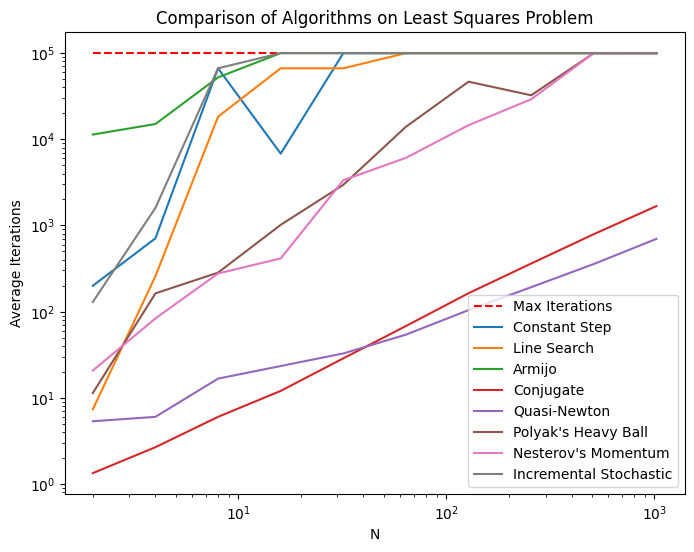

In [ ]:
# Plot the curve
plt.figure(figsize = (8,6))

max_it = 10 ** 5
plt.loglog(2 ** np.linspace(1, 10, 10), [max_it] * 10, "r--", label="Max Iterations")

plt.loglog(2 ** np.linspace(1, 10, 10), avg_its_constant_step, label="Constant Step")
plt.loglog(2 ** np.linspace(1, 10, 10), avg_its_line_search, label="Line Search")
plt.loglog(2 ** np.linspace(1, 10, 10), avg_its_armijo, label="Armijo")
plt.loglog(2 ** np.linspace(1, 10, 10), avg_its_conjugate, label="Conjugate")
plt.loglog(2 ** np.linspace(1, 10, 10), avg_its_quasi, label="Quasi-Newton")
plt.loglog(2 ** np.linspace(1, 10, 10), avg_its_polyak, label="Polyak's Heavy Ball")
plt.loglog(2 ** np.linspace(1, 10, 10), avg_its_nesterov, label="Nesterov's Momentum")
plt.loglog(2 ** np.linspace(1, 10, 10), avg_its_stochastic, label="Incremental Stochastic")

plt.title("Comparison of Algorithms on Least Squares Problem")
plt.xlabel("N")
plt.ylabel("Average Iterations")
plt.legend()
plt.show()

In [ ]:
# Empty array to store the average time
avg_time_constant_step = np.empty(10)
avg_time_line_search = np.empty(10)
avg_time_armijo = np.empty(10)
avg_time_conjugate = np.empty(10)
avg_time_quasi = np.empty(10)
avg_time_polyak = np.empty(10)
avg_time_nesterov = np.empty(10)
avg_time_stochastic = np.empty(10)

# Generate each average
for k in tqdm(range(1, 11)):
    time.sleep(1)
    # Set parameters and generate matrices
    N = 2 ** k

    # Compute average over 3 runs
    total_time_constant_step = 0
    total_time_line_search = 0
    total_time_armijo = 0
    total_time_conjugate = 0
    total_time_quasi = 0
    total_time_polyak = 0
    total_time_nesterov = 0
    total_time_stochastic = 0


    for i in range(3):
        A = np.random.random((N, N))
        b = np.random.random((N, 1))
        x0 = np.zeros((N, 1))
        ATA = A.T @ A
        ATb = A.T @ b
        df = lambda x: ATA @ x - ATb

        start_constant_step = time.time()
        constant_step(A, b, x0, tol, max_it)
        end_constant_step = time.time()
        total_time_constant_step += end_constant_step - start_constant_step

        start_line_search = time.time()
        line_search(A, b, x0, tol, max_it)
        end_line_search = time.time()
        total_time_line_search += end_line_search - start_line_search

        start_armijo = time.time()
        armijo(A, b, x0, tol, max_it)
        end_armijo = time.time()
        total_time_armijo += end_armijo - start_armijo

        start_conjugate = time.time()
        conjugate(A, b, x0, tol, max_it)
        end_conjugate = time.time()
        total_time_conjugate += end_conjugate - start_conjugate

        start_quasi = time.time()
        quasi(A, b, x0, tol, max_it)
        end_quasi = time.time()
        total_time_quasi += end_quasi - start_quasi

        start_polyak = time.time()
        polyak(A, b, x0, tol, max_it)
        end_polyak = time.time()
        total_time_polyak += end_polyak - start_polyak

        start_nesterov = time.time()
        nesterov(A, b, x0, tol, max_it)
        end_nesterov = time.time()
        total_time_nesterov += end_nesterov - start_nesterov

        start_stochastic = time.time()
        stochastic(A, b, x0, tol, max_it)
        end_stochastic = time.time()
        total_time_stochastic += end_stochastic - start_stochastic

    avg_time_constant_step[k-1] = total_time_constant_step / 3
    avg_time_line_search[k-1] = total_time_line_search / 3
    avg_time_armijo[k-1] = total_time_armijo / 3
    avg_time_conjugate[k-1] = total_time_conjugate / 3
    avg_time_quasi[k-1] = total_time_quasi / 3
    avg_time_polyak[k-1] = total_time_polyak / 3
    avg_time_nesterov[k-1] = total_time_nesterov / 3
    avg_time_stochastic[k-1] = total_time_stochastic / 3


  0%|          | 0/10 [00:00<?, ?it/s]<ipython-input-45-88746b3eba35>:26: LineSearchWarning: The line search algorithm did not converge
  alpha = sp.optimize.line_search(f, df_flat, x0.flatten(), u.flatten())[0]
<ipython-input-45-88746b3eba35>:33: RuntimeWarning: divide by zero encountered in scalar divide
  p = 1 / (g.T @ s)[0,0]
<ipython-input-45-88746b3eba35>:34: RuntimeWarning: invalid value encountered in multiply
  D = (I - p * s @ g.T) @ D @ (I - p * g @ s.T) + p * s @ s.T
<ipython-input-45-88746b3eba35>:34: RuntimeWarning: invalid value encountered in matmul
  D = (I - p * s @ g.T) @ D @ (I - p * g @ s.T) + p * s @ s.T
100%|██████████| 10/10 [1:33:43<00:00, 562.40s/it] 


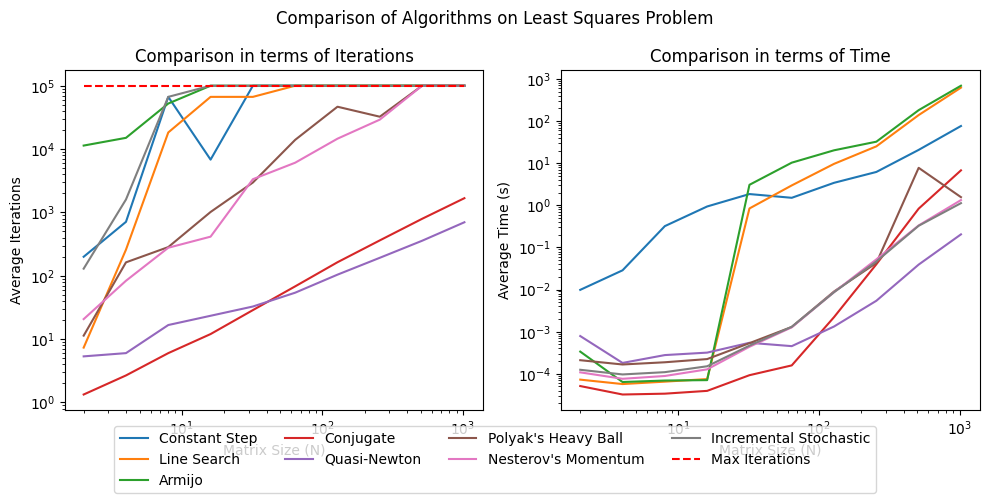

In [ ]:
# Create figure
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Comparison of Algorithms on Least Squares Problem")

# Plot the curves
axs[0].loglog(2 ** np.linspace(1, 10, 10), avg_its_constant_step, label="Constant Step")
axs[1].loglog(2 ** np.linspace(1, 10, 10), avg_time_constant_step, label="Constant Step")

axs[0].loglog(2 ** np.linspace(1, 10, 10), avg_its_line_search, label="Line Search")
axs[1].loglog(2 ** np.linspace(1, 10, 10), avg_time_line_search, label="Line Search")

axs[0].loglog(2 ** np.linspace(1, 10, 10), avg_its_armijo, label="Armijo")
axs[1].loglog(2 ** np.linspace(1, 10, 10), avg_time_armijo, label="Armijo")

axs[0].loglog(2 ** np.linspace(1, 10, 10), avg_its_conjugate, label="Conjugate")
axs[1].loglog(2 ** np.linspace(1, 10, 10), avg_time_conjugate, label="Conjugate")

axs[0].loglog(2 ** np.linspace(1, 10, 10), avg_its_quasi, label="Quasi-Newton")
axs[1].loglog(2 ** np.linspace(1, 10, 10), avg_time_quasi, label="Quasi-Newton")

axs[0].loglog(2 ** np.linspace(1, 10, 10), avg_its_polyak, label="Polyak's Heavy Ball")
axs[1].loglog(2 ** np.linspace(1, 10, 10), avg_time_polyak, label="Polyak's Heavy Ball")

axs[0].loglog(2 ** np.linspace(1, 10, 10), avg_its_nesterov, label="Nesterov's Momentum")
axs[1].loglog(2 ** np.linspace(1, 10, 10), avg_time_nesterov, label="Nesterov's Momentum")

axs[0].loglog(2 ** np.linspace(1, 10, 10), avg_its_stochastic, label="Incremental Stochastic")
axs[1].loglog(2 ** np.linspace(1, 10, 10), avg_time_stochastic, label="Incremental Stochastic")

# Plot maximum number of iterations
axs[0].loglog(2 ** np.linspace(1, 10, 10), [max_it] * 10, "r--", label="Max Iterations")

# Plot metadata
axs[0].set_title("Comparison in terms of Iterations")
axs[0].set_xlabel(r"Matrix Size (N)")
axs[0].set_ylabel("Average Iterations")

axs[1].set_title("Comparison in terms of Time")
axs[1].set_xlabel(r"Matrix Size (N)")
axs[1].set_ylabel("Average Time (s)")

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncols=4, bbox_to_anchor=(0.5, 0))
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.show()